Импорт библиотек

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr


Константы

In [2]:
FONTSIZE = 14
FIGSIZE1 = (15, 4)
FIGSIZE2 = (15, 10)

Просмотр сырых данных

In [3]:
data_raw = pd.read_excel("../data/raw/Global Superstore.xls", parse_dates=['Order Date', 'Ship Date'])

data_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# Первичный обзор

Просмотр типов данных и пропусков

In [4]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

Пропуски в столбце Postal Code - это нормально, не у каждой страны есть Postal Code. Типы данных верные

Построим перекрестную таблицу по Country и Postal Code, чтобы узнать, по какой причине пропуски в столбце Postal Code

In [5]:
crosstab_orders = pd.crosstab(
    data_raw["Postal Code"],
    data_raw["Country"],
    values=data_raw["Order ID"],
    aggfunc='count'
)

crosstab_orders

Country,United States
Postal Code,
1040.0,1
1453.0,6
1752.0,2
1810.0,4
1841.0,33
...,...
98502.0,5
98632.0,3
98661.0,5


In [6]:
data_raw["Country"].value_counts()

Country
United States    9994
Australia        2837
France           2827
Mexico           2644
Germany          2065
                 ... 
South Sudan         2
Bahrain             2
Swaziland           2
Burundi             2
Eritrea             2
Name: count, Length: 147, dtype: int64

Оказалось, что в датасете Postal Code указан лишь для заказов из США, хотя другие страны в датасете тоже есть.

Посмотрим статистики по числовым признакам

In [7]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]

data_raw[num_cols].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.610982,26.375818
std,487.565361,2.278766,0.212280,174.340972,57.296810
min,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,30.758625,2.000000,0.000000,0.000000,2.610000
50%,85.053000,3.000000,0.000000,9.240000,7.790000
75%,251.053200,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000


Посмотрим временной период всех заказов и создадим на основе Order Date столбцы Order Year, Order Quarter, Order Month, Order Day, и аналогично для Ship Date

In [8]:
print(f"Период заказов: с {data_raw['Order Date'].min()} по {data_raw['Order Date'].max()}")

print(f"Период доставок: с {data_raw['Ship Date'].min()} по {data_raw['Ship Date'].max()}")

Период заказов: с 2011-01-01 00:00:00 по 2014-12-31 00:00:00
Период доставок: с 2011-01-03 00:00:00 по 2015-01-07 00:00:00


In [9]:
data_processed = data_raw.copy()

data_processed["Order Year"] = data_processed["Order Date"].dt.year
data_processed["Order Quarter"] = data_processed["Order Date"].dt.quarter
data_processed["Order Month"] = data_processed["Order Date"].dt.month
data_processed["Order Day"] = data_processed["Order Date"].dt.day

data_processed["Ship Year"] = data_processed["Ship Date"].dt.year
data_processed["Ship Quarter"] = data_processed["Ship Date"].dt.quarter
data_processed["Ship Month"] = data_processed["Ship Date"].dt.month
data_processed["Ship Day"] = data_processed["Ship Date"].dt.day

data_processed[["Order Date", "Order Year", "Order Quarter", "Order Month", "Order Day"]]

,Order Date,Order Year,Order Quarter,Order Month,Order Day
0,2012-07-31,2012,3,7,31
1,2013-02-05,2013,1,2,5
2,2013-10-17,2013,4,10,17
3,2013-01-28,2013,1,1,28
4,2013-11-05,2013,4,11,5
...,...,...,...,...,...
51285,2014-06-19,2014,2,6,19
51286,2014-06-20,2014,2,6,20
51287,2013-12-02,2013,4,12,2
51288,2012-02-18,2012,1,2,18


Создадим календарь для более удобной работы в Power BI

In [10]:
calendar_df = pd.DataFrame({
    'Date': pd.date_range(
        start=data_processed['Order Date'].min(),
        end=data_processed['Ship Date'].max(),
        freq='D'
    )
})

calendar_df['Year'] = calendar_df['Date'].dt.year
calendar_df['Month'] = calendar_df['Date'].dt.month
calendar_df['Month_Name'] = calendar_df['Date'].dt.strftime('%B')
calendar_df['Quarter'] = calendar_df['Date'].dt.quarter
calendar_df['Weekday'] = calendar_df['Date'].dt.day_name()
calendar_df['Week_Num'] = calendar_df['Date'].dt.isocalendar().week

calendar_df.to_csv('../data/processed/calendar.csv', index=False)

calendar_df

,Date,Year,Month,Month_Name,Quarter,Weekday,Week_Num
0,2011-01-01,2011,1,January,1,Saturday,52
1,2011-01-02,2011,1,January,1,Sunday,52
2,2011-01-03,2011,1,January,1,Monday,1
3,2011-01-04,2011,1,January,1,Tuesday,1
4,2011-01-05,2011,1,January,1,Wednesday,1
...,...,...,...,...,...,...,...
1463,2015-01-03,2015,1,January,1,Saturday,1
1464,2015-01-04,2015,1,January,1,Sunday,1
1465,2015-01-05,2015,1,January,1,Monday,2
1466,2015-01-06,2015,1,January,1,Tuesday,2


# Исследовательский анализ данных

## Анализ продаж и прибыли

### Расчет базовых метрик:

- общие продажи
- общая прибыль
- общее количество заказов
- общее количество клиентов
- средняя маржинальность
- средний чек
- средняя скидка

In [11]:
total_sales = data_processed["Sales"].sum()
total_profit = data_processed["Profit"].sum()
orders_count = data_processed["Order ID"].nunique()
customers_count = data_processed["Customer ID"].nunique()
mean_margin = total_profit / total_sales * 100
mean_order = total_sales / orders_count
mean_discount = data_processed["Discount"].mean()

print(f"Общие продажи: ${total_sales:,.3f}")
print(f"Общая прибыль: ${total_profit:,.3f}")
print(f"Общее количество уникальных заказов: {orders_count}")
print(f"Общее количество уникальных клиентов: {customers_count}")
print(f"Средняя маржинальность: {mean_margin:,.2f}%")
print(f"Средний чек: ${mean_order:,.3f}")
print(f"Средняя скидка: {mean_discount:,.2f}")

Общие продажи: $12,642,501.910
Общая прибыль: $1,467,457.291
Общее количество уникальных заказов: 25035
Общее количество уникальных клиентов: 1590
Средняя маржинальность: 11.61%
Средний чек: $504.993
Средняя скидка: 0.14


#### Выводы

Клиентов почти в 16 раз меньше, чем заказов - очень лояльная аудитория.

Довольно большая средняя скидка.

### Анализ убытков:

- количество заказов с отрицательной прибылью
- процент от общего количества заказов
- сумма потерь
- средний убыток на один убыточный заказ

In [12]:
orders_with_loss_count = data_processed["Order ID"][data_processed["Profit"] < 0].nunique()
total_loss = data_processed["Profit"][data_processed["Profit"] < 0].sum()
mean_loss_per_order = total_loss / orders_with_loss_count

print(f"Общее количество уникальных заказов с отрицательной прибылью: {orders_with_loss_count}")
print(f"Процент от общего количества заказов: {orders_with_loss_count / orders_count * 100:,.2f}%")
print(f"Общие убытки: ${abs(total_loss):,.3f}")
print(f"Средний убыток на один убыточный заказ: ${abs(mean_loss_per_order):,.3f}")

Общее количество уникальных заказов с отрицательной прибылью: 7541
Процент от общего количества заказов: 30.12%
Общие убытки: $920,646.156
Средний убыток на один убыточный заказ: $122.085


#### Выводы

Почти каждый третий заказ убыточный. При этом общая прибыль выходит в плюс лишь за счет 70% заказов с высокой маржинальностью.

### Распределение:

- гистограмма распределения продаж
- гистограмма распределения прибыли
- гистограмма распределения скидок

Найти выбросы

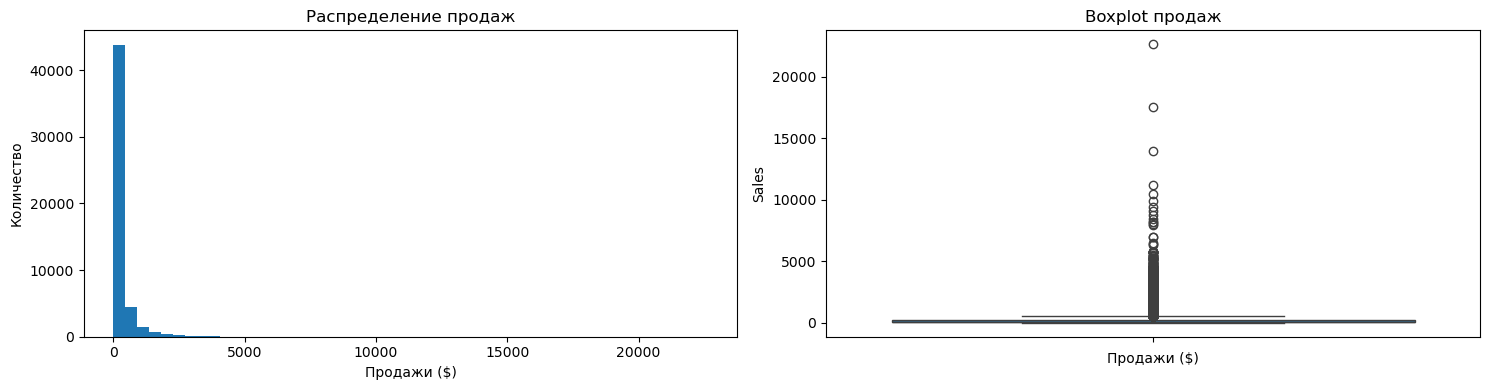

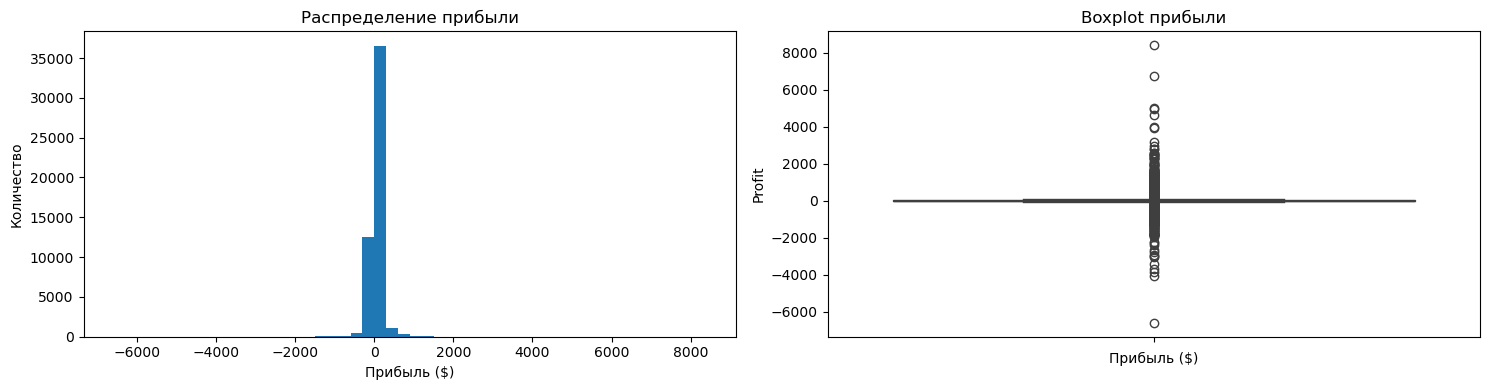

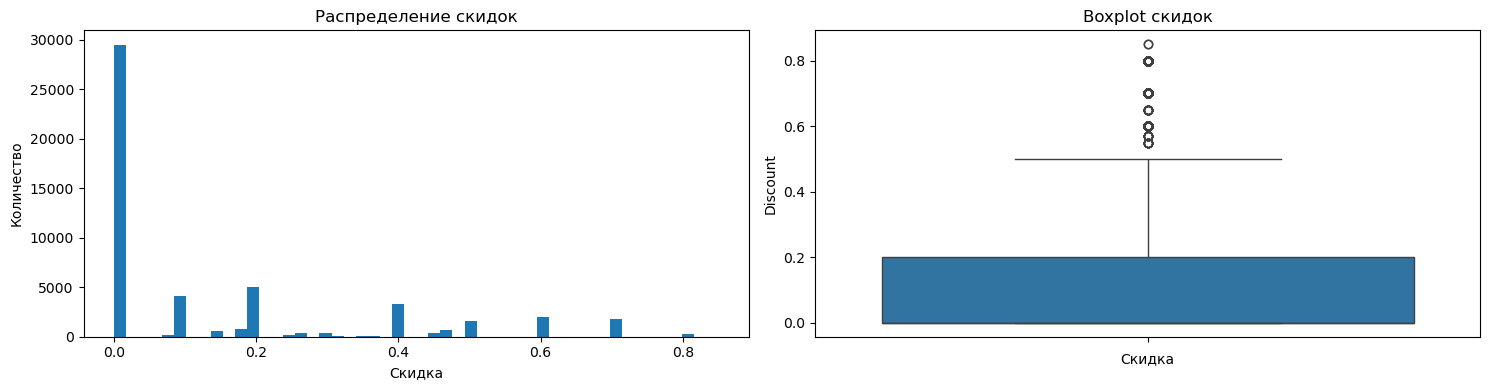

In [13]:
plt.figure(figsize=FIGSIZE1)
plt.subplot(1, 2, 1)
plt.hist(data_processed["Sales"], bins=50)
plt.title("Распределение продаж")
plt.xlabel("Продажи ($)")
plt.ylabel("Количество")
plt.subplot(1, 2, 2)
sns.boxplot(data_processed["Sales"])
plt.title("Boxplot продаж")
plt.xlabel("Продажи ($)")
plt.tight_layout()
plt.show()

plt.figure(figsize=FIGSIZE1)
plt.subplot(1, 2, 1)
plt.hist(data_processed["Profit"], bins=50)
plt.title("Распределение прибыли")
plt.xlabel("Прибыль ($)")
plt.ylabel("Количество")
plt.subplot(1, 2, 2)
sns.boxplot(data_processed["Profit"])
plt.title("Boxplot прибыли")
plt.xlabel("Прибыль ($)")
plt.tight_layout()
plt.show()

plt.figure(figsize=FIGSIZE1)
plt.subplot(1, 2, 1)
plt.hist(data_processed["Discount"], bins=50)
plt.title("Распределение скидок")
plt.xlabel("Скидка")
plt.ylabel("Количество")
plt.subplot(1, 2, 2)
sns.boxplot(data_processed["Discount"])
plt.title("Boxplot скидок")
plt.xlabel("Скидка")
plt.tight_layout()
plt.show()

#### Выводы

Распределение продаж имеет правостороннюю асимметрию (скошено вправо). Основной объем заказов (более 75%) не превышает $500, однако присутствуют редкие крупные транзакции, формирующие "длинный хвост" распределения. Наличие выбросов подтверждается боксплотом.

Около 30% заказов демонстрируют отрицательную прибыль, что является критической точкой для бизнеса. При этом как положительные, так и отрицательные выбросы указывают на высокую волатильность показателя. (Волатильность - это показатель изменчивости или нестабильности данных).

Распределение скидок имеет пик в нуле (заказы без скидки). Далее наблюдается дискретное равномерное распределение с шагом 0.1 (10%, 20%, 40%). Это свидетельствует о том, что скидки в компании задаются не гибко, а по фиксированным маркетинговым правилам.

## Анализ по категориям

### Сгруппировать по категориям и рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов
- маржинальность
- долю в общих продажах

Формат для больших чисел в DataFrame через `.to_string(float_format = '{:,.2f}'.format)`

In [14]:
orders_by_category = data_processed.groupby(by="Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count"
})
orders_by_category.columns = ["Total_Sales", "Total_Profit", "Orders_Count"]

orders_by_category["Margin"] = orders_by_category["Total_Profit"] / orders_by_category["Total_Sales"] * 100

orders_by_category["Total_Sales_Proportion"] = orders_by_category["Total_Sales"] / total_sales

orders_by_category = orders_by_category.sort_values("Total_Profit", ascending=False)

print(orders_by_category.to_string(float_format = '{:,.2f}'.format))

                 Total_Sales  Total_Profit  Orders_Count  Margin  Total_Sales_Proportion
Category                                                                                
Technology      4,744,557.50    663,778.73         10141   13.99                    0.38
Office Supplies 3,787,070.23    518,473.83         31273   13.69                    0.30
Furniture       4,110,874.19    285,204.72          9876    6.94                    0.33


### Сгруппировать по подкатегориям и рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов
- маржинальность
- долю в общих продажах

In [15]:
orders_by_subcategory = data_processed.groupby(by="Sub-Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count"
})
orders_by_subcategory.columns = ["Total_Sales", "Total_Profit", "Orders_Count"]

orders_by_subcategory["Margin"] = orders_by_subcategory["Total_Profit"] / orders_by_subcategory["Total_Sales"] * 100

orders_by_subcategory["Total_Sales_Proportion"] = orders_by_subcategory["Total_Sales"] / total_sales

orders_by_subcategory = orders_by_subcategory.sort_values("Total_Profit", ascending=False)

print(orders_by_subcategory.to_string(float_format = '{:,.2f}'.format))

              Total_Sales  Total_Profit  Orders_Count  Margin  Total_Sales_Proportion
Sub-Category                                                                         
Copiers      1,509,436.27    258,567.55          2223   17.13                    0.12
Phones       1,706,824.14    216,717.01          3357   12.70                    0.14
Bookcases    1,466,572.24    161,924.42          2411   11.04                    0.12
Appliances   1,011,064.30    141,680.59          1755   14.01                    0.08
Chairs       1,501,681.76    140,396.27          3434    9.35                    0.12
Accessories    749,237.02    129,626.31          3075   17.30                    0.06
Storage      1,127,085.86    108,461.49          5059    9.62                    0.09
Binders        461,911.51     72,449.85          6152   15.68                    0.04
Paper          244,291.72     59,207.68          3538   24.24                    0.02
Machines       779,060.07     58,867.87          1486 

### Создать scatter plot: Sales vs Profit и разделить на 4 квадранта:

- высокие продажи, высокая прибыль
- высокие продажи, низкая прибыль
- низкие продажи, высокая прибыль
- низкие продажи, низкая прибыль

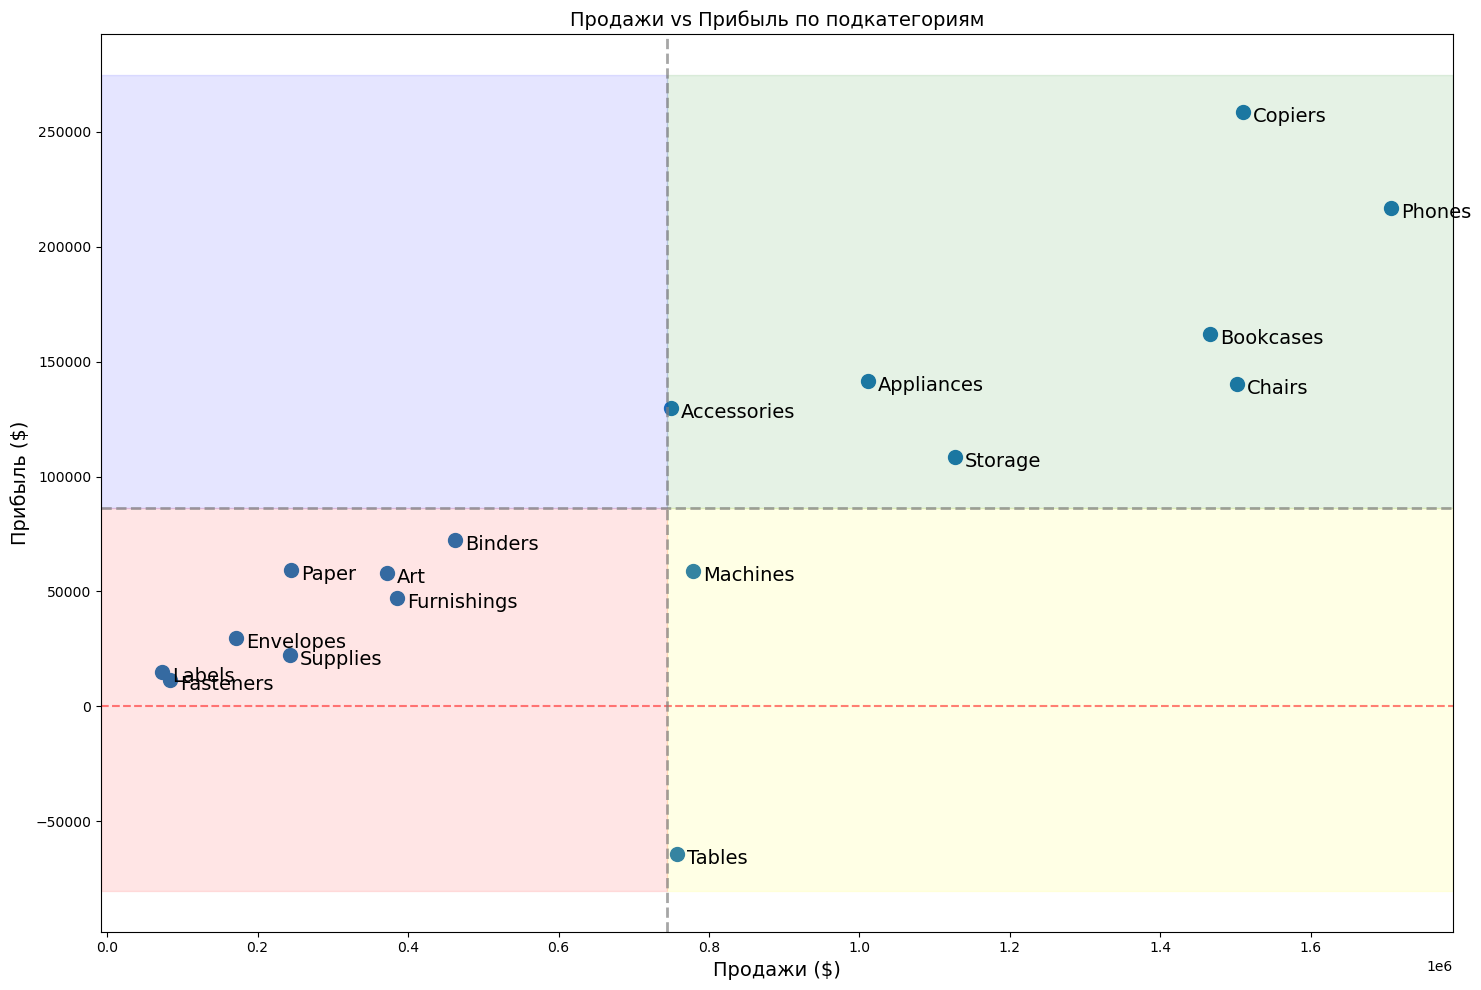

Средние продажи: $743,677
Средняя прибыль: $86,321


In [16]:
plt.figure(figsize=FIGSIZE2)
plt.scatter(
    x=orders_by_subcategory["Total_Sales"],
    y=orders_by_subcategory["Total_Profit"],
    s=100,
)
for i, row in orders_by_subcategory.iterrows():
    plt.annotate(
        i,
        (row["Total_Sales"], row["Total_Profit"]),
        xytext=(10, -10),
        textcoords="offset pixels",
        fontsize=FONTSIZE,
    )

plt.title("Продажи vs Прибыль по подкатегориям", fontsize=FONTSIZE)
plt.xlabel("Продажи ($)", fontsize=FONTSIZE)
plt.ylabel("Прибыль ($)", fontsize=FONTSIZE)

plt.axhline(y=0, color="red", linestyle="--", alpha=0.5)

avg_sales = orders_by_subcategory["Total_Sales"].mean()
avg_profit = orders_by_subcategory["Total_Profit"].mean()
plt.axvline(x=avg_sales, color="gray", linestyle="--", linewidth=2, alpha=0.7)
plt.axhline(y=avg_profit, color="gray", linestyle="--", linewidth=2, alpha=0.7)

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.axhspan(avg_profit, y_max, xmin=(avg_sales - x_min) / (x_max - x_min), color="green", alpha=0.1)
plt.axhspan(avg_profit, y_max, xmin=0, xmax=(avg_sales - x_min) / (x_max - x_min), color="blue", alpha=0.1)
plt.axhspan(ymin=y_min, ymax=avg_profit, xmin=(avg_sales - x_min) / (x_max - x_min), color="yellow", alpha=0.1)
plt.axhspan(ymin=y_min, ymax=avg_profit, xmin=0, xmax=(avg_sales - x_min) / (x_max - x_min), color="red", alpha=0.1)

plt.tight_layout()
plt.show()

print(f"Средние продажи: ${avg_sales:,.0f}")
print(f"Средняя прибыль: ${avg_profit:,.0f}")

#### Выводы

Интерпретация осей и линий

- Ось X - Продажи ($). Чем правее точка, тем больше выручка у подкатегории.
- Ось Y - Прибыль ($). Чем выше точка, тем больше прибыль.
- Вертикальная линия - средний уровень продаж по всем подкатегориям.
- Горизонтальная линия - средний уровень прибыли по всем подкатегориям.

Точки делятся на 4 квадранта:

| Квадрант | Характеристика                   | Стратегия                                 | Подкатегории |
|:--------:|:--------------------------------:|:-----------------------------------------:|:------------:|
| Зеленый  | Высокие продажи, высокая прибыль | Инвестировать, развивать                  | Copiers, Phones, Bookcases, Chairs, Storage, Appliances, Accessories |
| Синий    | Низкие продажи, высокая прибыль  | Анализировать, можно масштабировать       | Нет |
| Желтый   | Высокие продажи, низкая прибыль  | Сокращать затраты, повышать цены, уходить | Machines, Tables |
| Красный  | Низкие продажи, низкая прибыль   | Поддерживать, не вкладывать много         | Labels, Binders, Paper, Art, Furnishings, Envelopes, Supplies, Fasteners |

**Tables** - единственная подкатегория с отрицательной прибылью (`-$64,083`). Почему?

In [17]:
tables_data = data_processed[data_processed["Sub-Category"] == "Tables"]

tables_orders_count = tables_data["Order ID"].nunique()
tables_mean_sales = tables_data["Sales"].mean()
tables_mean_discount = tables_data["Discount"].mean()
tables_median_discount = tables_data["Discount"].median()

print(f"Общее количество уникальных заказов Tables: {orders_count}")
print(f"Средняя цена Tables: ${tables_mean_sales:,.2f}")
print(f"Средняя скидка Tables: {tables_mean_discount:,.2f}")
print(f"Медианная скидка Tables: {tables_median_discount:,.2f}")

Общее количество уникальных заказов Tables: 25035
Средняя цена Tables: $879.26
Средняя скидка Tables: 0.29
Медианная скидка Tables: 0.30


In [18]:
tables_discount_groups = tables_data.groupby(pd.cut(tables_data["Discount"], bins=np.arange(0.0, 1.1, 0.1))).agg({
    "Profit": "sum",
    "Sales": "sum",
    "Order ID": "count"
})
tables_discount_groups.columns = ["Total_Profit", "Total_Sales", "Orders_Count"]

tables_discount_groups["Margin"] = tables_discount_groups["Total_Profit"] / tables_discount_groups["Total_Sales"] * 100

tables_discount_groups

C:\Users\shsas\AppData\Local\Temp\ipykernel_11372\1089945038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tables_discount_groups = tables_data.groupby(pd.cut(tables_data["Discount"], bins=np.arange(0.0, 1.1, 0.1))).agg({


,Total_Profit,Total_Sales,Orders_Count,Margin
Discount,,,,
"(0.0, 0.1]",795.0270,3481.4070,3,22.836370
"(0.1, 0.2]",7215.5360,157722.7360,183,4.574823
"(0.2, 0.3]",-11960.4786,104750.2890,116,-11.418086
"(0.3, 0.4]",-26227.8298,106316.4930,130,-24.669578
"(0.4, 0.5]",-29326.4400,67040.7424,99,-43.744205
"(0.5, 0.6]",-20057.0520,28356.6680,50,-70.731343
"(0.6, 0.7]",-34283.7910,23426.7390,58,-146.344700
"(0.7, 0.8]",-7616.9020,3340.6580,12,-228.006040
"(0.8, 0.9]",-3068.6580,796.8420,2,-385.102442


#### Выводы

При скидках до 20% заказы подкатегории Tables приносят прибыль, при больших скидках становятся убыточными. Большинство заказов товаров подкатегории Tables были с 20% скидкой и более. 

## Анализ по сегментам клиентов

### Сгруппировать по сегментам и рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов
- количество клиентов
- маржинальность
- средний чек
- количество заказов на клиента

In [19]:
customers_by_segments = data_processed.groupby(data_processed["Segment"]).agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count",
    "Customer ID": "count",
})
customers_by_segments.columns = ["Total_Sales", "Total_Profit", "Orders_Count", "Customers_Count"]

customers_by_segments["Margin"] = customers_by_segments["Total_Profit"] / customers_by_segments["Total_Sales"] * 100
customers_by_segments["Mean_Sales_Per_Customer"] = customers_by_segments["Total_Sales"] / customers_by_segments["Customers_Count"]
customers_by_segments["Mean_Orders_Count_Per_Customer"] = customers_by_segments["Orders_Count"] / customers_by_segments["Customers_Count"]


print(customers_by_segments.to_string(float_format = '{:,.2f}'.format))

             Total_Sales  Total_Profit  Orders_Count  Customers_Count  Margin  Mean_Sales_Per_Customer  Mean_Orders_Count_Per_Customer
Segment                                                                                                                               
Consumer    6,507,949.42    749,239.78         26518            26518   11.51                   245.42                            1.00
Corporate   3,824,697.52    441,208.33         15429            15429   11.54                   247.89                            1.00
Home Office 2,309,854.97    277,009.18          9343             9343   11.99                   247.23                            1.00


#### Выводы

Все сегменты имеют схожую маржинальность, Consumer - самый большой сегмент по объему. Каждый клиент сделал только 1 заказ в наборе данных.

### Для каждого сегмента найти:

- самую популярную категорию
- самый популярный способ доставки
- среднюю скидку
- среднее время доставки

In [20]:
data_processed["Ship Duration Days"] = (data_processed["Ship Date"] - data_processed["Order Date"]).dt.days

customers_by_segments = data_processed.groupby(data_processed["Segment"]).agg({
    "Category": lambda x: x.mode()[0],
    "Ship Mode": lambda x: x.mode()[0],
    "Discount": "mean",
    "Ship Duration Days": "mean",
})
customers_by_segments.columns = ["Mode_Category", "Mode_Ship_Mode", "Mean_Discount", "Mean_Ship_Duration"]

customers_by_segments

,Mode_Category,Mode_Ship_Mode,Mean_Discount,Mean_Ship_Duration
Segment,,,,
Consumer,Office Supplies,Standard Class,0.143602,3.953692
Corporate,Office Supplies,Standard Class,0.142931,3.994037
Home Office,Office Supplies,Standard Class,0.140897,3.973135


#### Выводы

Все сегменты имеют одинаковый паттерн: все закупают чаще всего Office Supplies, выбирают Standart Class доставку и скидки и время доставки почти равны.

## Временной анализ (сезонность)

### Для каждого месяца рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов

Вывести в виде столбчатой диаграммы

             Total_Sales  Total_Profit  Orders_Count
Order Month                                         
1             675,133.67     73,535.38          2599
2             543,739.38     70,932.20          2168
3             770,500.94     94,087.52          3035
4             698,561.21     73,513.63          3057
5             904,012.34    104,509.78          3747
6           1,269,716.75    147,079.42          5331
7             749,381.84     78,070.09          3166
8           1,293,833.17    151,854.11          5078
9           1,437,380.11    170,438.18          5975
10          1,168,184.39    157,269.36          4490
11          1,551,277.34    175,449.48          6342
12          1,580,780.77    170,718.13          6302


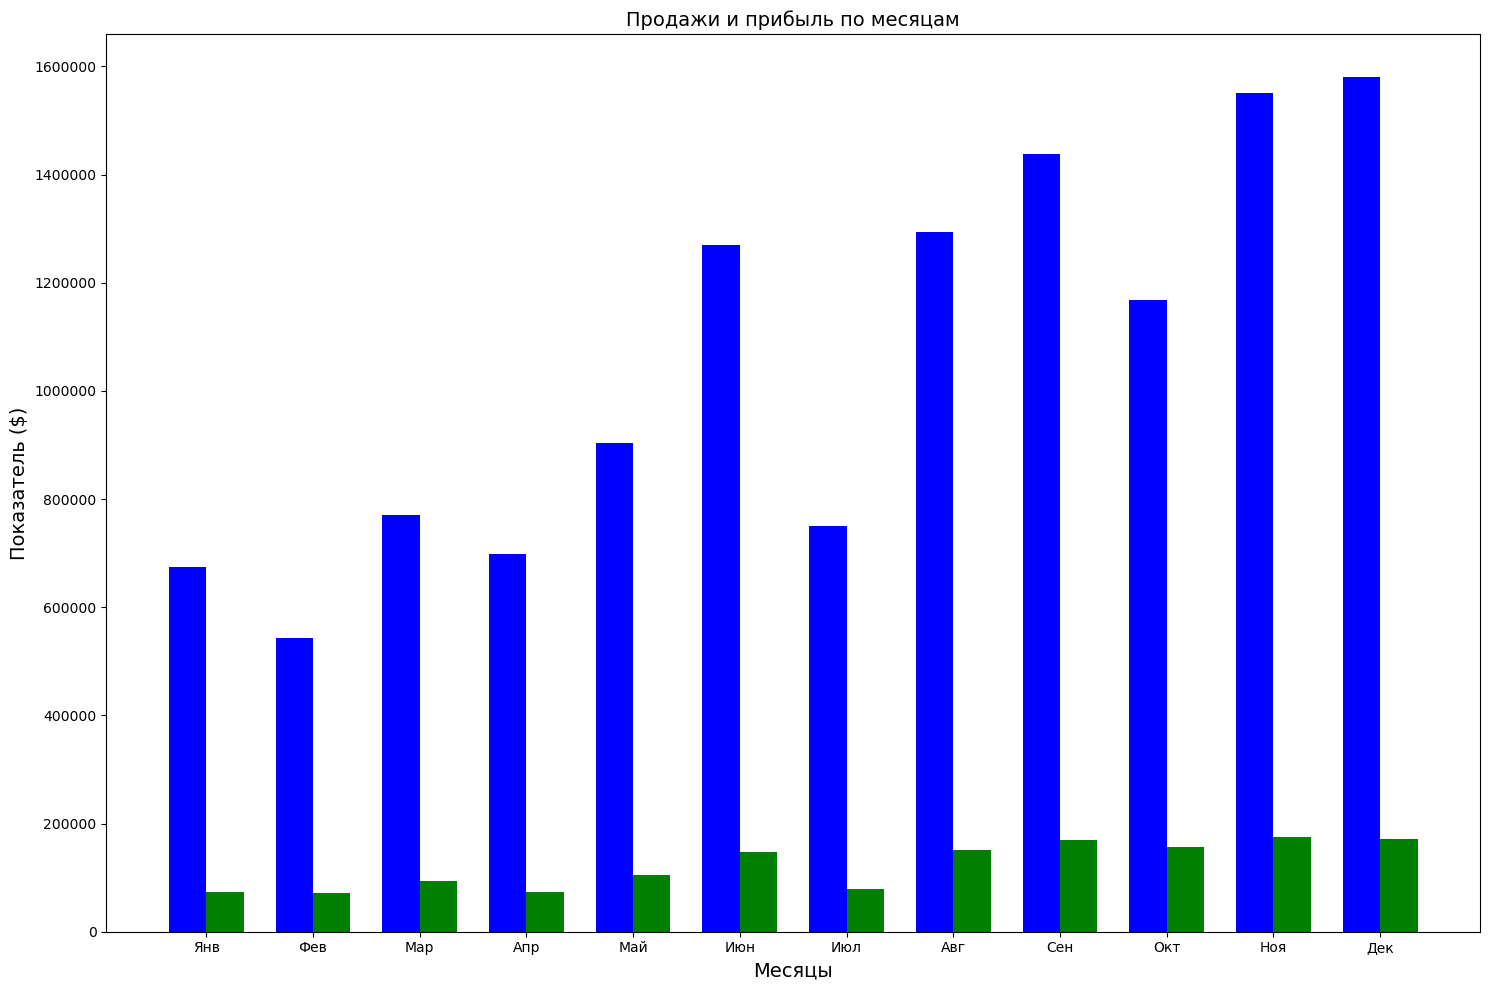

In [21]:
orders_by_months = data_processed.groupby(data_processed["Order Month"]).agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count",
})
orders_by_months.columns = ["Total_Sales", "Total_Profit", "Orders_Count"]

print(orders_by_months.to_string(float_format = '{:,.2f}'.format))

fig, ax1 = plt.subplots(figsize=FIGSIZE2)
x = np.arange(len(orders_by_months))
width = 0.35

sales_bars = ax1.bar(x - width/2, orders_by_months["Total_Sales"], width, label="Sales", color="blue")
profit_bars = ax1.bar(x + width/2, orders_by_months["Total_Profit"], width, label="Profit", color="green")

plt.title("Продажи и прибыль по месяцам", fontsize=FONTSIZE)
ax1.set_xlabel("Месяцы", fontsize=FONTSIZE)
ax1.set_ylabel("Показатель ($)", fontsize=FONTSIZE)
ax1.set_xticks(x)
ax1.set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
ax1.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

#### Выводы

Пик продаж в конце года (сентябрь-декабрь), спад - в январе-апреле.

### Для каждого года рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов

Рассчитать рост год к году

            Total_Sales  Total_Profit  Orders_Count  Margin
Order Year                                                 
2011       2,259,450.90    248,940.81          8998   11.02
2012       2,677,438.69    307,415.28         10962   11.48
2013       3,405,746.45    406,935.23         13799   11.95
2014       4,299,865.87    504,165.97         17531   11.73


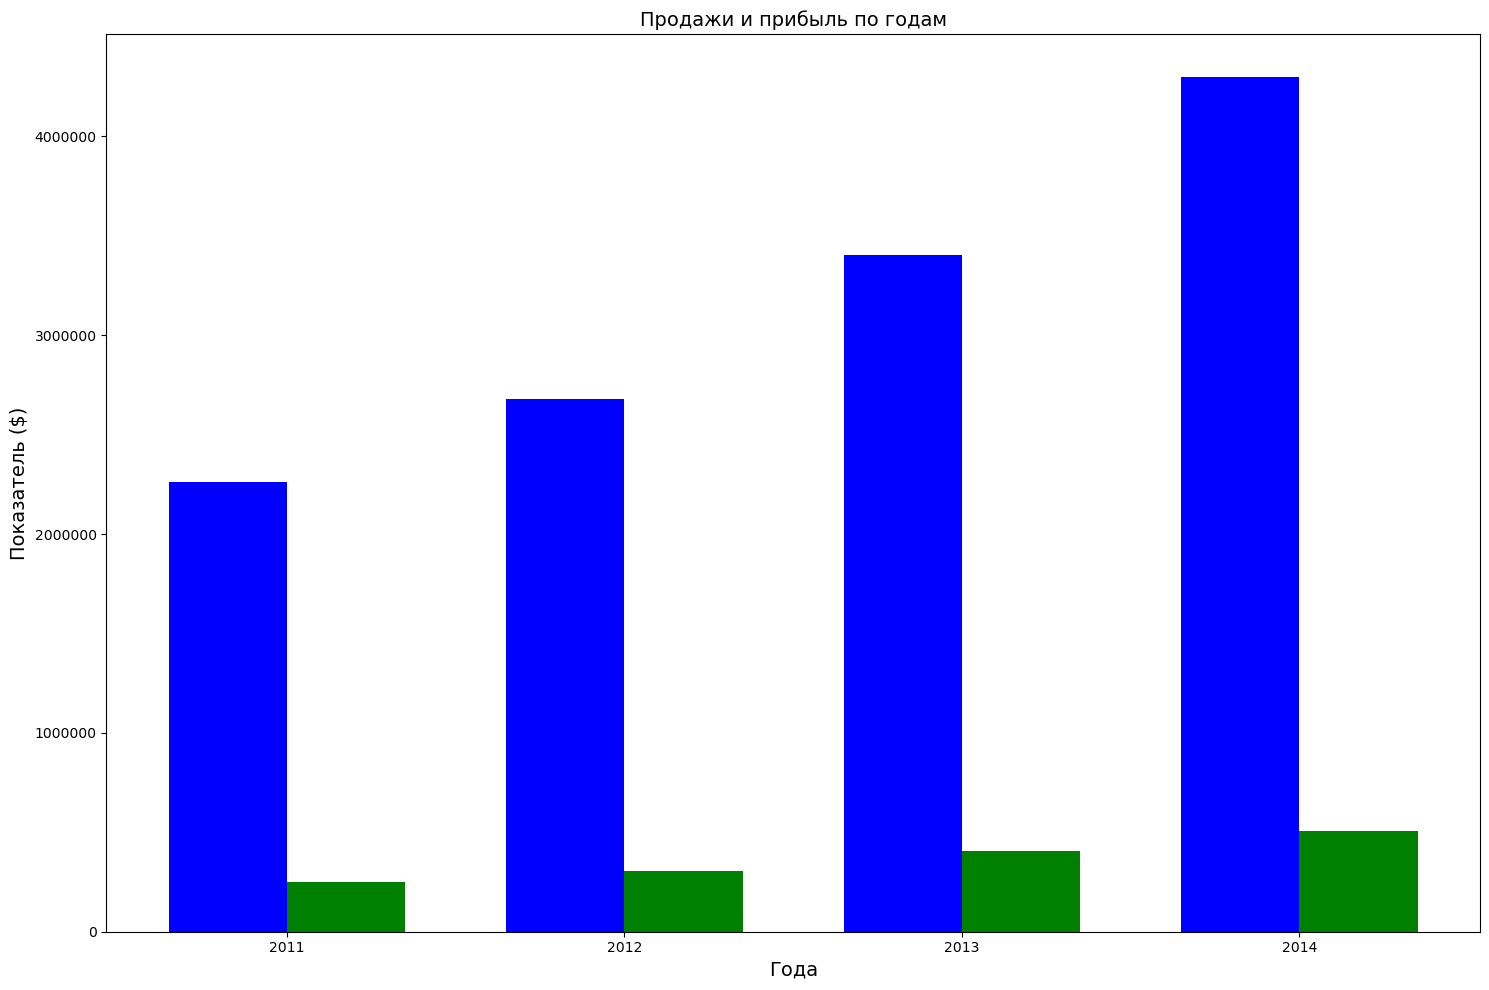

Темпы роста продаж по годам в %
Order Year
2011          NaN
2012    18.499530
2013    27.201659
2014    26.253259
Name: Total_Sales, dtype: float64
Темпы роста прибыли по годам в %
Order Year
2011          NaN
2012    23.489305
2013    32.373131
2014    23.893419
Name: Total_Profit, dtype: float64
Темпы роста количества заказов по годам в %
Order Year
2011          NaN
2012    21.827073
2013    25.880314
2014    27.045438
Name: Orders_Count, dtype: float64
Темпы роста маржинальности заказов по годам в %
Order Year
2011         NaN
2012    4.210798
2013    4.065569
2014   -1.869131
Name: Margin, dtype: float64


In [22]:
orders_by_years = data_processed.groupby(data_processed["Order Year"]).agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count",
})
orders_by_years.columns = ["Total_Sales", "Total_Profit", "Orders_Count"]

orders_by_years["Margin"] = orders_by_years["Total_Profit"] / orders_by_years["Total_Sales"] * 100

print(orders_by_years.to_string(float_format = '{:,.2f}'.format))

fig, ax1 = plt.subplots(figsize=FIGSIZE2)
x = np.arange(len(orders_by_years))
width = 0.35

sales_bars = ax1.bar(x - width/2, orders_by_years["Total_Sales"], width, label="Sales", color="blue")
profit_bars = ax1.bar(x + width/2, orders_by_years["Total_Profit"], width, label="Profit", color="green")

plt.title("Продажи и прибыль по годам", fontsize=FONTSIZE)
ax1.set_xlabel("Года", fontsize=FONTSIZE)
ax1.set_ylabel("Показатель ($)", fontsize=FONTSIZE)
ax1.set_xticks(x)
ax1.set_xticklabels(['2011', '2012', '2013', '2014'])
ax1.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print("Темпы роста продаж по годам в %")
print(orders_by_years["Total_Sales"].pct_change() * 100)
print("Темпы роста прибыли по годам в %")
print(orders_by_years["Total_Profit"].pct_change() * 100)
print("Темпы роста количества заказов по годам в %")
print(orders_by_years["Orders_Count"].pct_change() * 100)
print("Темпы роста маржинальности заказов по годам в %")
print(orders_by_years["Margin"].pct_change() * 100)

#### Выводы

Ежегодно стабильно растет прибыль и продажи, а также количество заказов, практически прямо пропорционально. Прибыль растет чуть быстрее продаж Маржинальность стабильно растет, небольшой спад в 2014.

## Анализ скидок

### Построить гистограмму и найти:

- среднюю скидку
- медианную скидку
- процент заказов без скидки
- процент заказов с высокой скидкой

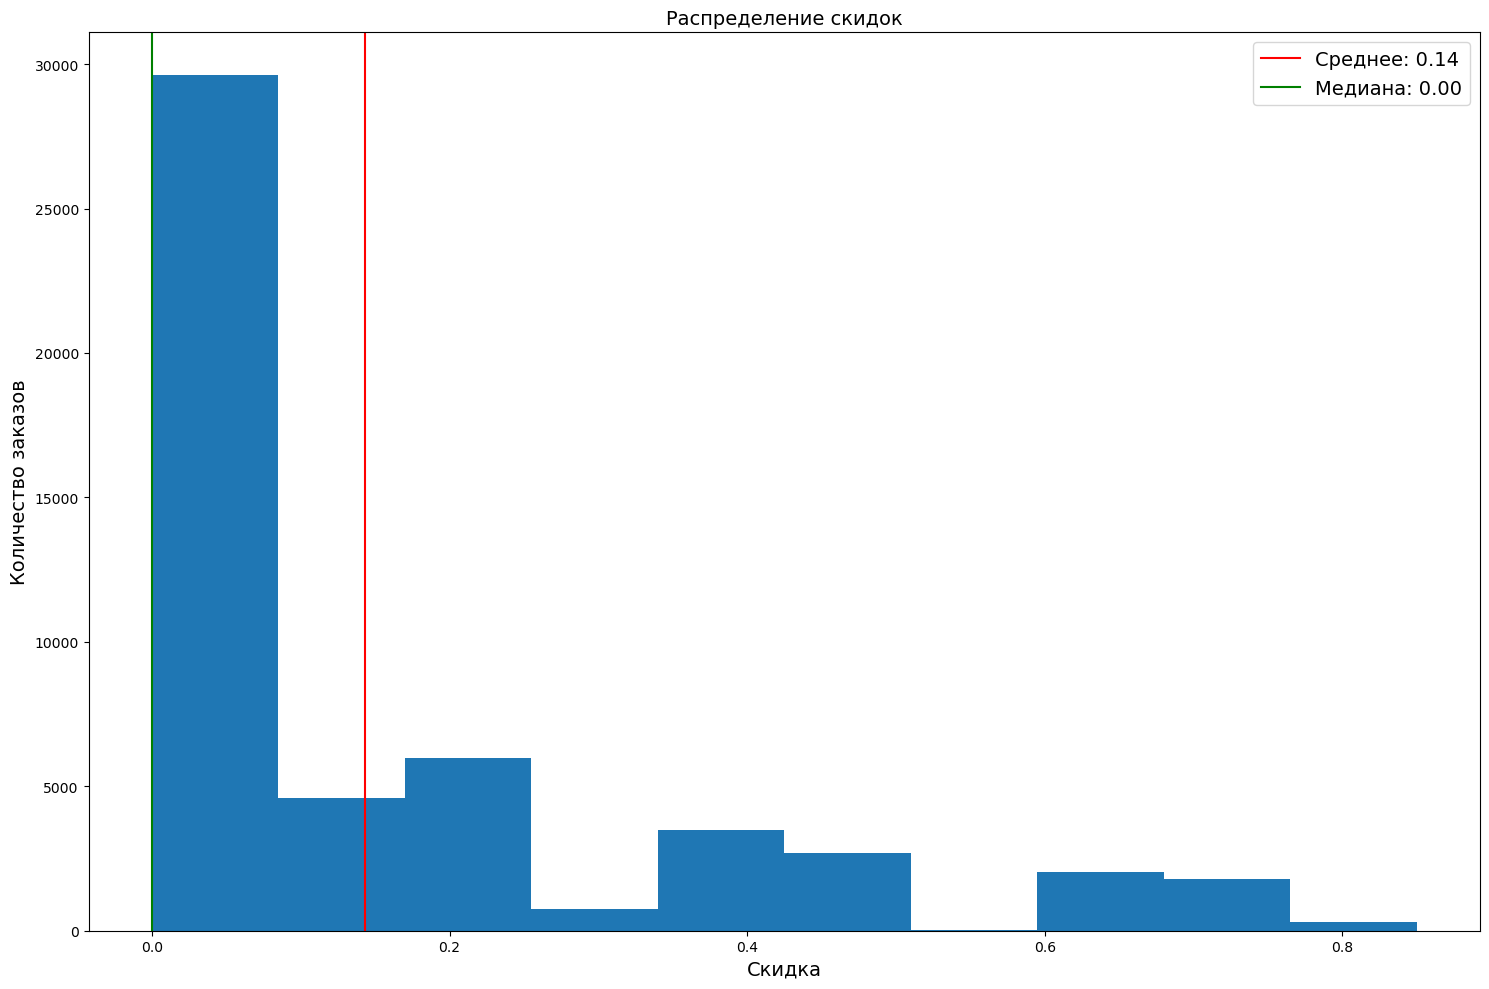

Заказов без скидки: 56.56%
Заказов со скидкой более 50%: 8.13%


In [23]:
plt.figure(figsize=FIGSIZE2)
plt.hist(x=data_processed["Discount"])
mean_val = data_processed["Discount"].mean()
median_val = data_processed["Discount"].median()
plt.axvline(x=mean_val, color="red", label=f"Среднее: {mean_val:.2f}")
plt.axvline(x=median_val, color="green", label=f"Медиана: {median_val:.2f}")
plt.title("Распределение скидок", fontsize=FONTSIZE)
plt.xlabel("Скидка", fontsize=FONTSIZE)
plt.ylabel("Количество заказов", fontsize=FONTSIZE)
plt.legend(fontsize=FONTSIZE)
plt.tight_layout()
plt.show()

print(f"Заказов без скидки: {len(data_processed[data_processed['Discount'] == 0]) / len(data_processed) * 100:.2f}%")
print(f"Заказов со скидкой более 50%: {len(data_processed[data_processed['Discount'] > 0.5]) / len(data_processed) * 100:.2f}%")

#### Выводы

56.56% заказов продаются без скидки, это поддерживает маржинальность. Основные скидки находятся в диапазоне 10-30%, что является рыночной нормой.

8.13% заказов имеют скидку более 50% - это критически много. Такие скидки убивают прибыль и должны быть пересмотрены.

Скидки имеют дискретный характер (шаг примерно 10%). Это говорит о том, что скидки задаются правилами, а не гибко.

### Сгруппировать по диапазонам скидок и для каждого рассчитать:

- количество заказов
- среднюю прибыль на заказ
- маржинальность
- корреляцию скидки и прибыли

In [24]:
discount_groups = data_processed.groupby(pd.cut(data_processed["Discount"], bins=np.arange(0.0, 1.1, 0.1))).agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count",
})
discount_groups.columns = ["Total_Sales", "Total_Profit", "Orders_Count"]

discount_groups["Mean_Profit_Per_Order"] = discount_groups["Total_Profit"] / discount_groups["Orders_Count"]
discount_groups["Margin"] = discount_groups["Total_Profit"] / discount_groups["Total_Sales"] * 100

print(discount_groups.to_string(float_format = '{:,.2f}'.format))

            Total_Sales  Total_Profit  Orders_Count  Mean_Profit_Per_Order  Margin
Discount                                                                          
(0.0, 0.1] 1,962,618.85    338,189.26          4679                  72.28   17.23
(0.1, 0.2] 1,757,261.34    173,254.84          6274                  27.61    9.86
(0.2, 0.3]   382,554.69    -21,155.61           967                 -21.88   -5.53
(0.3, 0.4]   701,343.12   -166,115.45          3400                 -48.86  -23.69
(0.4, 0.5]   474,688.31   -214,829.37          2789                 -77.03  -45.26
(0.5, 0.6]   199,035.33   -173,418.91          2028                 -85.51  -87.13
(0.6, 0.7]   151,329.16   -197,477.87          1826                -108.15 -130.50
(0.7, 0.8]    20,463.33    -38,616.23           316                -122.20 -188.71
(0.8, 0.9]       796.84     -3,068.66             2              -1,534.33 -385.10
(0.9, 1.0]         0.00          0.00             0                    NaN     NaN


C:\Users\shsas\AppData\Local\Temp\ipykernel_11372\3770143923.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_groups = data_processed.groupby(pd.cut(data_processed["Discount"], bins=np.arange(0.0, 1.1, 0.1))).agg({


In [25]:
corr_all = data_processed["Discount"].corr(data_processed["Profit"])
discount_positive = data_processed[data_processed["Discount"] > 0]
corr_positive = discount_positive["Discount"].corr(discount_positive["Profit"])
print(f"Корреляция скидки и прибыли (по всем заказам): {corr_all}")
print(f"Корреляция скидки и прибыли (только со скидкой > 0): {corr_positive}")

Корреляция скидки и прибыли (по всем заказам): -0.31649017182726474
Корреляция скидки и прибыли (только со скидкой > 0): -0.3531968866832404


Проверим значимость корреляции с помощью стат. тестов

H0 (Нулевая гипотеза): Скидка не влияет на прибыль.

H1 (Альтернативная гипотеза): Скидка влияет на прибыль.

Уровень значимости alpha = 0.05 (вероятность ошибки первого рода)

Данные не имеют нормальное распределение, имеются сильные выбросы. Поэтому используется корреляция Спирмена

In [26]:
alpha = 0.05

spearman_corr, spearman_p = spearmanr(data_processed["Discount"], data_processed["Profit"])

print(f"Коэффициент Спирмена: {spearman_corr:.4f}")
print(f"p-value: {spearman_p:.10f}")

if spearman_p < alpha:
    print(f"Результат статистически значим (p < {alpha})")
    print("Связь между скидкой и прибылью не случайна. Нулевая гипотеза отвергается")
else:
    print(f"Нет оснований утверждать, что результат статистически значим (p >= {alpha})")
    print("Связь может быть случайной. Альтернативная гипотеза принимается")

Коэффициент Спирмена: -0.5960
p-value: 0.0000000000
Результат статистически значим (p < 0.05)
Связь между скидкой и прибылью не случайна. Нулевая гипотеза отвергается


#### Выводы

Если судить по всем заказам, то скидки до 20% прибыльны (как и с Tables), скидки от 20% - убыточны. Маржинальность падает с 17.23% до -5.53% при переходе через 20% скидку.

70% всех убытков от скидок приходятся на диапазон 30-60%.

При увеличении скидки прибыль имеет устойчивую тенденцию к снижению. Связь статистически значимая.

### Сгруппировать по категориям и рассчитать:

- среднюю скидку
- маржинальность
- корреляцию скидки и прибыли в этой категории

In [27]:
orders_by_category = data_processed.groupby(by="Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
})
orders_by_category.columns = ["Total_Sales", "Total_Profit", "Mean_Discount"]

orders_by_category["Margin"] = orders_by_category["Total_Profit"] / orders_by_category["Total_Sales"] * 100

corrs = {}
p_values = {}

for category in data_processed["Category"].unique():
    cat_data = data_processed[data_processed["Category"] == category]
    corr, p_val = spearmanr(cat_data["Discount"], cat_data["Profit"])
    corrs[category] = corr
    p_values[category] = p_val

orders_by_category["Corr_Discount_Profit"] = orders_by_category.index.map(corrs)
orders_by_category["Corr_p_value"] = orders_by_category.index.map(p_values)

print(orders_by_category.to_string(float_format = '{:,.2f}'.format))

                 Total_Sales  Total_Profit  Mean_Discount  Margin  Corr_Discount_Profit  Corr_p_value
Category                                                                                             
Furniture       4,110,874.19    285,204.72           0.17    6.94                 -0.68          0.00
Office Supplies 3,787,070.23    518,473.83           0.14   13.69                 -0.61          0.00
Technology      4,744,557.50    663,778.73           0.14   13.99                 -0.59          0.00


#### Выводы

Во всех категориях скидки статистически значимо снижают прибыль. Сильнее всего скидки снижают прибыль в категории Furniture (-0.68). Также в этой категории самая высокая средняя скидка и самая низкая маржинальность.

## Географический анализ

### Сгруппировать по странам и рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов
- количество клиентов
- маржинальность

Найти топ-10 стран по продажам и топ-5 стран с лучшей маржинальностью

### Сгруппировать по рынкам и рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов
- количество клиентов
- маржинальность

Найти самый прибыльный и самый убыточный рынки

### Сгруппировать по рынкам+регионам и рассчитать:

- сумму продаж
- сумму прибыли
- количество заказов
- количество клиентов
- маржинальность

### Детальный анализ по США. Найти для каждого штата:

- сумму продаж
- сумму прибыли
- количество заказов
- количество клиентов
- маржинальность

# Ключевые инсайты для дашборда

# Сохранение данных для Power BI